In [3]:
import pandas as pd
import plotly.express as px

In [5]:
df = pd.read_csv('projetos-fnma-1990-a-2024-dados-abertos-2025.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()
df = df.rename(columns={df.columns[0]: 'Ano'})
df['Região Geográfica'] = df['Região Geográfica'].str.strip()
df.head()

,Ano,Nº do Instrumento de Repasse,Nº Interno,Tema,Instituição Executora,Título do Projeto,UF,Região Geográfica,Cidade da Instituição Executora,Bioma,Esfera Institucional,Data Assinatura,Data de Publicação no DOU,Data de Fim da Vigência,Recursos do FNMA (R$),Recursos de CP (R$),Valor Total do Projeto (R$),Tipo de Seleção do Projeto,Edital ou Termo de Referência de Origem do Projeto
0,1990,NaN,CV001/90,Educação Ambiental,Fundação Nacional do Índio - Funai,I Encontro sobre Meio Ambiente Indígena,DF,Centro-Oeste,NaN,Cerrado,Federal,07/12/1990,NaN,31/12/1990,"2.837,01",0,"2.837,01",Demanda Espontânea (DE),NaN
1,1990,NaN,CV002/90,Gestão de Áreas Protegidas,Núcleo de Cultura Indígena da União das Nações...,Serra do Roncador/Xavante: Manejo Indígena de ...,GO,Centro-Oeste,NaN,Cerrado,OSC,14/11/1990,NaN,31/12/1990,"41.212,07",0,"41.212,07",Demanda Espontânea (DE),NaN
2,1990,NaN,CV003/90,Conservação e Manejo da Biodiversidade,Fundação Pró-natureza – Funatura,Conservação da Avifauna da Amazônia,DF,Centro-Oeste,NaN,Amazônia,OSC,13/11/1990,NaN,31/12/1990,"22.907,20",0,"22.907,20",Demanda Espontânea (DE),NaN
3,1990,NaN,CV004/90,Gestão de Áreas Protegidas,Núcleo de Cultura Indígena da União das Nações...,Metareilá/Suruí: Manejo Indígena de Floresta T...,GO,Centro-Oeste,NaN,Amazônia,OSC,14/11/1990,NaN,31/12/1990,"88.484,75",0,"88.484,75",Demanda Espontânea (DE),NaN
4,1990,NaN,CV005/90,Amazônia Sustentável,Prefeitura Municipal de Curralinho,Extensão Florestal e Pesquisa nas Áreas das Fl...,AM,Norte,NaN,Amazônia,Municipal,13/11/1990,22/11/1990,31/12/1990,"304.654,39",0,"304.654,39",Demanda Espontânea (DE),NaN


In [6]:
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")
print(f"Colunas: {list(df.columns)}")

Total de linhas: 1495
Total de colunas: 19
Colunas: ['Ano', 'Nº do Instrumento de Repasse', 'Nº  Interno', 'Tema', 'Instituição Executora', 'Título do Projeto', 'UF', 'Região Geográfica', 'Cidade da Instituição Executora', 'Bioma', 'Esfera Institucional', 'Data Assinatura', 'Data de Publicação no DOU', 'Data de Fim da Vigência', 'Recursos do FNMA (R$)', 'Recursos de CP (R$)', 'Valor Total do Projeto (R$)', 'Tipo de Seleção do Projeto', 'Edital ou Termo de Referência de Origem do Projeto']


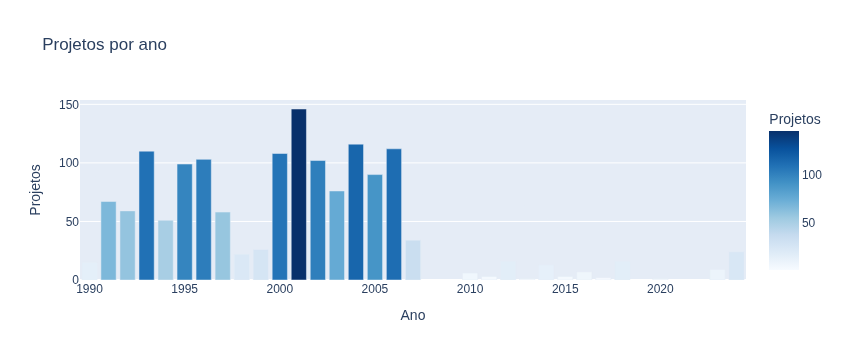

In [7]:
por_ano = df.groupby('Ano').size().reset_index(name='Projetos')

px.bar(por_ano, x='Ano', y='Projetos',
       title='Projetos por ano',
       color='Projetos',
       color_continuous_scale='Blues')

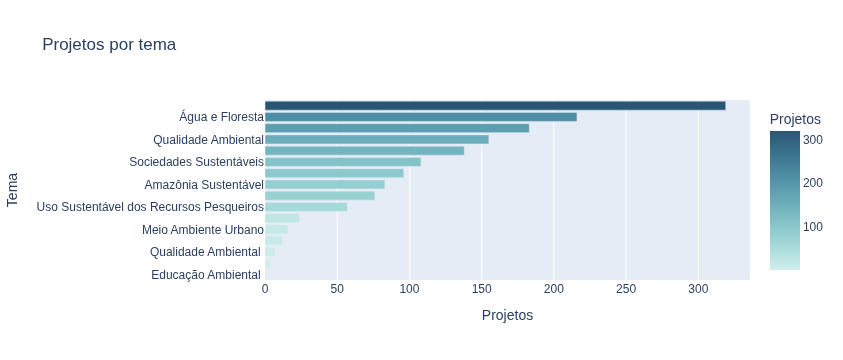

In [8]:
por_tema = df['Tema'].value_counts().reset_index()
por_tema.columns = ['Tema', 'Projetos']
por_tema = por_tema.sort_values('Projetos')

px.bar(por_tema, x='Projetos', y='Tema',
       orientation='h',
       title='Projetos por tema',
       color='Projetos',
       color_continuous_scale='Teal')

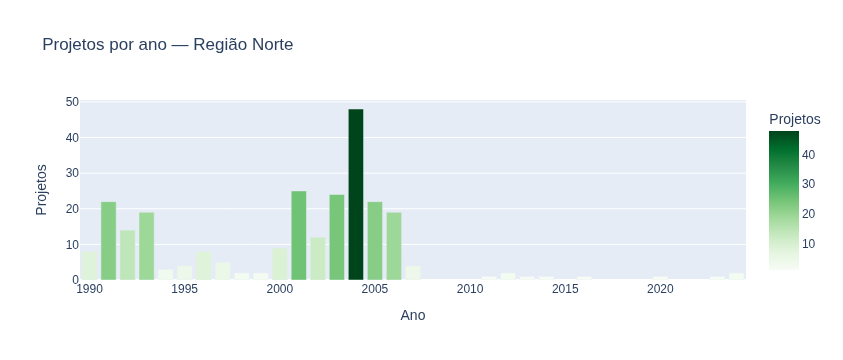

In [9]:
regiao = 'Norte'  # mude aqui para explorar

df_filtrado = df[df['Região Geográfica'] == regiao]
por_ano_filtrado = df_filtrado.groupby('Ano').size().reset_index(name='Projetos')

px.bar(por_ano_filtrado, x='Ano', y='Projetos',
       title=f'Projetos por ano — Região {regiao}',
       color='Projetos',
       color_continuous_scale='Greens')